In [1]:
import xarray as xr
import numpy as np
import os, sys
from collections import OrderedDict as odict

sys.path.append('/Users/yunpeichu/LS2D')
sys.path.append('/Users/yunpeichu/py/')
import ls2d
import dales_ls2d_tools as dlt

In [2]:
from thermo import get_theta_l

In [4]:
scmin = xr.open_dataset('/Users/yunpeichu/dales_MOSAiC/ayil_config_input_results/20191016/scm_in.a_year_in_les.20191016.nc', decode_times=False)

In [20]:
# Load sonde data
NSA_path = '/Users/yunpeichu/Arctic_data/ARM-NSA'
prof_sonde_file = 'nsasondewnpnC1.b1/nsasondewnpnC1.b1.20221120.052900.cdf'
NSA_sonde = xr.open_dataset(os.path.join(NSA_path, prof_sonde_file))
NSA_sonde

<xarray.Dataset> Size: 488kB
Dimensions:      (time: 4694)
Coordinates:
  * time         (time) datetime64[ns] 38kB 2022-11-20T05:29:00 ... 2022-11-2...
Data variables: (12/24)
    base_time    datetime64[ns] 8B ...
    time_offset  (time) datetime64[ns] 38kB ...
    pres         (time) float32 19kB ...
    qc_pres      (time) int32 19kB ...
    tdry         (time) float32 19kB ...
    qc_tdry      (time) int32 19kB ...
    ...           ...
    wstat        (time) float32 19kB ...
    asc          (time) float32 19kB ...
    qc_asc       (time) int32 19kB ...
    lat          (time) float32 19kB ...
    lon          (time) float32 19kB ...
    alt          (time) float32 19kB ...
Attributes: (12/32)
    command_line:               sonde_ingest -s nsa -f C1
    Conventions:                ARM-1.2
    process_version:            ingest-sonde-10.14-1.el7
    dod_version:                sondewnpn-b1-2.3
    input_source:               /data/collection/nsa/nsasondeC1.00/good.2022N...
    site_id:                    nsa
    ...                         ...
    latitude_calculation:       lat[k-1]+((v_wind[k]-v_wind[k-1])/2)*delta_ti...
    longitude_calculation:      lon[k-1]+((u_wind[k]-u_wind[k-1])/2)*delta_ti...
    sonde_pc_software_version:  2.19
    sounding_number:            ///
    doi:                        10.5439/1595321
    history:                    created by user dsmgr on machine prod-proc3.a...

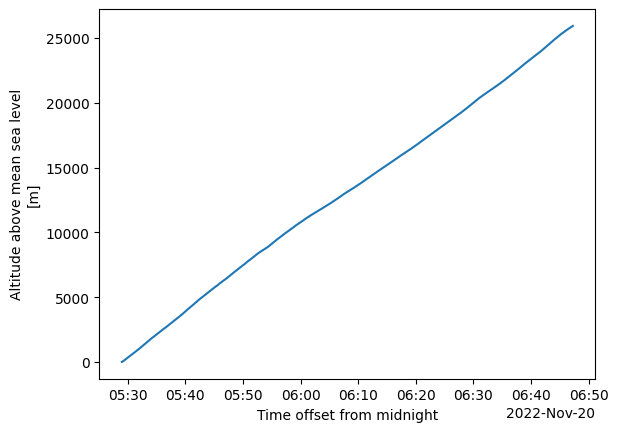

In [21]:
NSA_sonde['alt'].plot()

In [22]:
# --- Step 1: Filter by QC flags (keep only qc == 0) ---
qc_vars = {
    'pres': 'qc_pres',
    'tdry': 'qc_tdry',
    'rh':   'qc_rh',
    'u_wind': 'qc_u_wind',
    'v_wind': 'qc_v_wind',
}

ds = NSA_sonde.copy()
for var, qc_var in qc_vars.items():
    ds[var] = ds[var].where(ds[qc_var] == 0)

# Also mask altitude where pressure is bad (needed for interpolation)
valid = ds['pres'].notnull() & ds['tdry'].notnull() & ds['rh'].notnull()
ds = ds.where(valid, drop=True)

print(f"Sonde points after QC filtering: {len(ds.time)} / {len(NSA_sonde.time)}")

Sonde points after QC filtering: 4694 / 4694


In [23]:
# --- Step 2: Convert sonde variables to DALES variables ---

T_K = ds['tdry'].values + 273.15   # Temperature in K
p_hPa = ds['pres'].values          # Pressure in hPa
p_Pa = p_hPa * 100.0               # Pressure in Pa
rh = ds['rh'].values               # Relative humidity in %
alt = ds['alt'].values             # Altitude in m

# Liquid water potential temperature (no liquid water in sonde, q_c = 0)
thl = get_theta_l(T_K, p_Pa, q_c=0.0)

# Specific humidity from RH:
# Saturation vapour pressure (Bolton 1980): es = 6.112 * exp(17.67*T_C / (T_C + 243.5))
T_C = ds['tdry'].values
e_sat = 6.112 * np.exp(17.67 * T_C / (T_C + 243.5))  # hPa
e = (rh / 100.0) * e_sat                               # hPa
# Mixing ratio and specific humidity
w = 0.622 * e / (p_hPa - e)        # kg/kg
qt = w / (1.0 + w)                  # kg/kg

u = ds['u_wind'].values
v = ds['v_wind'].values

print(f"Altitude range: {np.nanmin(alt):.0f} - {np.nanmax(alt):.0f} m")
print(f"thl range: {np.nanmin(thl):.1f} - {np.nanmax(thl):.1f} K")
print(f"qt range: {np.nanmin(qt)*1000:.3f} - {np.nanmax(qt)*1000:.3f} g/kg")

Altitude range: 14 - 25929 m
thl range: 266.3 - 637.7 K
qt range: 0.003 - 2.269 g/kg


In [24]:
# --- Step 3: Define DALES grid and interpolate ---

# Same grid as nsa_input.py
grid = ls2d.grid.Grid_linear_stretched(kmax=176, dz0=20, alpha=0.009)

# Interpolate sonde profiles onto DALES grid
# Remove NaNs before interpolation
mask = np.isfinite(alt) & np.isfinite(thl) & np.isfinite(qt) & np.isfinite(u) & np.isfinite(v)

thl_dales = np.interp(grid.z, alt[mask], thl[mask])
qt_dales  = np.interp(grid.z, alt[mask], qt[mask])
u_dales   = np.interp(grid.z, alt[mask], u[mask])
v_dales   = np.interp(grid.z, alt[mask], v[mask])

init_tke = 0.1
tke_dales = np.ones(grid.kmax) * init_tke

print(f"DALES grid: {grid.kmax} levels, z = {grid.z[0]:.1f} - {grid.z[-1]:.1f} m")
print(f"Sonde max alt (valid): {alt[mask].max():.0f} m")
if grid.z[-1] > alt[mask].max():
    print(f"WARNING: DALES grid top ({grid.z[-1]:.0f} m) exceeds sonde max alt ({alt[mask].max():.0f} m).")
    print("  Values above sonde top are extrapolated (constant).")

DALES grid: 176 levels, z = 10.0 - 8485.4 m
Sonde max alt (valid): 25929 m


In [25]:
# --- Step 4: Write prof.inp.001 ---

expnr = 1
docstring = 'NSA sonde 2022-11-01 11:04 UTC'

output = odict([
    ('z (m)',          grid.z),
    ('thl (K)',        thl_dales),
    ('qt (kg kg-1)',   qt_dales),
    ('u (m s-1)',      u_dales),
    ('v (m s-1)',      v_dales),
    ('tke (m2 s-2)',   tke_dales),
])

out_dir = '/Users/yunpeichu/LS2D/results/NSA/run_sonde'
os.makedirs(out_dir, exist_ok=True)

fname = os.path.join(out_dir, f'prof.inp.{expnr:03d}')
dlt.write_profiles(fname, output, grid.kmax, docstring)
print(f"Written: {fname}")

 - Saving /Users/yunpeichu/LS2D/results/NSA/run_sonde/prof.inp.001
Written: /Users/yunpeichu/LS2D/results/NSA/run_sonde/prof.inp.001


In [26]:
import matplotlib.pyplot as plt

def read_prof_inp(path):
    """Read prof.inp file, return dict of arrays."""
    with open(path) as f:
        header = f.readline().strip()  # docstring
        cols = f.readline().split()
    data = np.loadtxt(path, skiprows=2)
    return header, cols, data

era5_header, era5_cols, era5_data = read_prof_inp('/Users/yunpeichu/LS2D/results/NSA/run_era5/prof.inp.001')
sonde_header, sonde_cols, sonde_data = read_prof_inp('/Users/yunpeichu/LS2D/results/NSA/run_sonde/prof.inp.001')

# Columns: z, thl, qt, u, v, tke
labels = ['thl (K)', 'qt (kg/kg)', 'u (m/s)', 'v (m/s)']
col_idx = [1, 2, 3, 4]

fig, axes = plt.subplots(1, 4, figsize=(14, 6), sharey=True)

for ax, ci, lab in zip(axes, col_idx, labels):
    ax.plot(era5_data[:, ci], era5_data[:, 0], label='ERA5')
    ax.plot(sonde_data[:, ci], sonde_data[:, 0], label='Sonde', ls='--')
    ax.set_ylim(0,3000)
    ax.set_xlabel(lab)
    ax.legend()

axes[0].set_ylabel('z (m)')
fig.suptitle(f'prof.inp comparison\nERA5: {era5_header}\nSonde: {sonde_header}', fontsize=10)
plt.tight_layout()
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/Users/yunpeichu/LS2D/results/NSA/run_era5/prof.inp.001'